# Agent-Based Model Flowchart

This notebook creates a visual representation of our agent-based model structure, showing how different components interact and the overall simulation flow. The flowchart highlights key processes including environment initialization, agent behaviors, model steps, and data collection mechanisms.

In [11]:
# Import required libraries
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib import patches

import matplotlib.patches as mpat

In [2]:
# Define model components and relationships
model_components = {
    # Initialization components
    'initialization': ['Model Initialization', 'Environment Setup', 'Agent Creation'],

    # Environment components
    'environment': ['Permanent Factors', 'Yearly Changing Factors', 'Spatial Grid'],

    # Agent components
    'agents': ['Farmer Agent', 'Agent Attributes', 'Agent Decision-Making', 'Agent Adaptation'],

    # Model flow components
    'model_flow': ['Setup Phase', 'Step Method', 'Year Cycle', 'Simulation Run'],

    # Data collection components
    'data': ['Data Collectors', 'Agent-Level Data', 'Environment-Level Data', 'Output Analysis']
}

# Define relationships between components (source, target)
relationships = [
    # Initialization flow
    ('Model Initialization', 'Environment Setup'),
    ('Environment Setup', 'Permanent Factors'),
    ('Environment Setup', 'Spatial Grid'),
    ('Model Initialization', 'Agent Creation'),
    ('Agent Creation', 'Farmer Agent'),

    # Environment relationships
    ('Permanent Factors', 'Yearly Changing Factors'),
    ('Yearly Changing Factors', 'Agent Decision-Making'),
    ('Spatial Grid', 'Agent Decision-Making'),

    # Agent relationships
    ('Farmer Agent', 'Agent Attributes'),
    ('Agent Attributes', 'Agent Decision-Making'),
    ('Agent Decision-Making', 'Agent Adaptation'),

    # Model flow
    ('Setup Phase', 'Step Method'),
    ('Step Method', 'Year Cycle'),
    ('Year Cycle', 'Yearly Changing Factors'),
    ('Year Cycle', 'Agent Decision-Making'),
    ('Step Method', 'Simulation Run'),

    # Data collection
    ('Agent Adaptation', 'Agent-Level Data'),
    ('Yearly Changing Factors', 'Environment-Level Data'),
    ('Agent-Level Data', 'Data Collectors'),
    ('Environment-Level Data', 'Data Collectors'),
    ('Data Collectors', 'Output Analysis'),
    ('Output Analysis', 'Simulation Run')
]

In [4]:
# Create directed graph
G = nx.DiGraph()

# Add nodes to graph
for category, components in model_components.items():
    for component in components:
        G.add_node(component, category=category)

# Add edges to graph
for source, target in relationships:
    G.add_edge(source, target)

In [12]:
# Set up visual properties for the flowchart
plt.figure(figsize=(14, 10))

# Define node positions using a hierarchical layout
pos = nx.multipartite_layout(G, subset_key="category", align='horizontal', scale=2.0)

# Adjust vertical spacing for better readability
max_y = max(pos.values(), key=lambda x: x[1])[1]
min_y = min(pos.values(), key=lambda x: x[1])[1]
y_spread = max_y - min_y

# Define colors and shapes for different categories
node_colors = {
    'initialization': '#FF9999',  # Light red
    'environment': '#99FF99',     # Light green
    'agents': '#9999FF',          # Light blue
    'model_flow': '#FFFF99',      # Light yellow
    'data': '#FF99FF'             # Light purple
}

# Create node color list
node_color_list = [node_colors[G.nodes[n]['category']] for n in G.nodes()]

# Node size and shape properties
node_size = 2500
edge_width = 1.5
arrow_size = 20
font_size = 10

# Create a legend
legend_elements = [
    patches.Patch(color=color, label=category.capitalize())
    for category, color in node_colors.items()]

<Figure size 1400x1000 with 0 Axes>

<module 'matplotlib.pyplot' from 'C:\\Users\\Owner\\anaconda3\\envs\\environment_Model\\Lib\\site-packages\\matplotlib\\pyplot.py'>

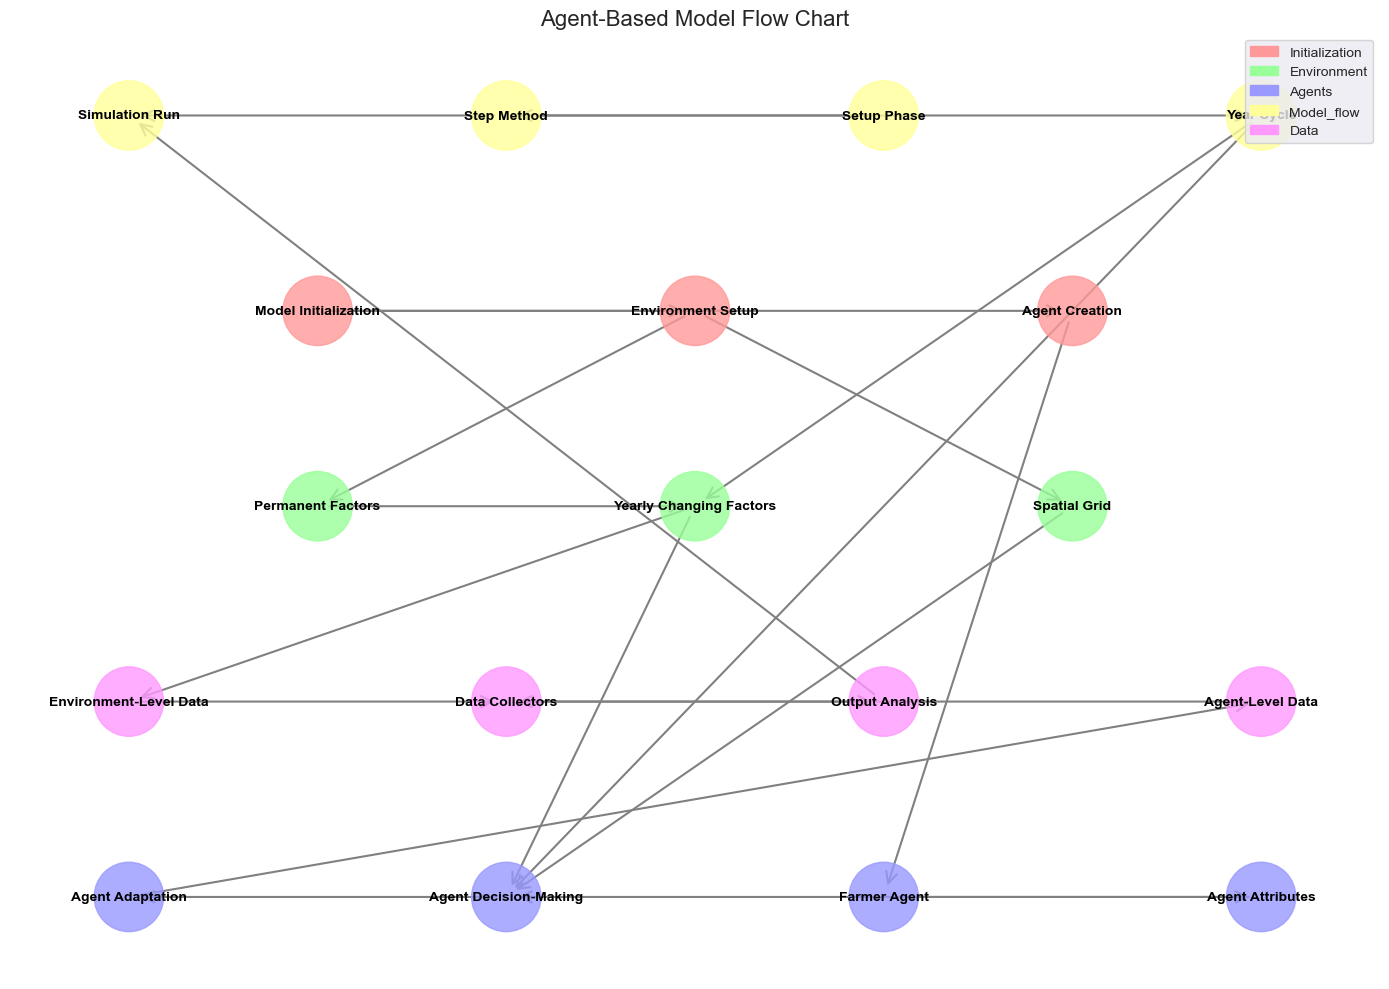

In [13]:
# Draw the flowchart
plt.figure(figsize=(14, 10))

# Draw edges with arrows
nx.draw_networkx_edges(
    G, pos,
    width=edge_width,
    arrowsize=arrow_size,
    arrowstyle='->',
    edge_color='gray'
)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    nodelist=G.nodes(),
    node_color=node_color_list,
    node_size=node_size,
    node_shape='o',
    alpha=0.8
)

# Draw labels
nx.draw_networkx_labels(
    G, pos,
    font_size=font_size,
    font_weight='bold'
)

# Add legend
plt.legend(handles=legend_elements, loc='upper right')

# Remove axis
plt.axis('off')

# Add title
plt.title('Agent-Based Model Flow Chart', fontsize=16)

# Show the plot
plt.tight_layout()
plt

## Key Components Explanation

### Initialization (Red)
- **Model Initialization**: Starting point that triggers environment and agent setup
- **Environment Setup**: Creation of the simulation world and conditions
- **Agent Creation**: Population of the model with farmer agents

### Environment (Green)
- **Permanent Factors**: Fixed environmental conditions that don't change (topography, soil quality)
- **Yearly Changing Factors**: Dynamic conditions that evolve annually (weather, market prices)
- **Spatial Grid**: Geographic representation of the model landscape

### Agents (Blue)
- **Farmer Agent**: Individual decision-making entity in the model
- **Agent Attributes**: Properties of each agent (resources, land holdings, knowledge)
- **Agent Decision-Making**: How agents evaluate options and choose actions
- **Agent Adaptation**: How agents learn and change behaviors over time

### Model Flow (Yellow)
- **Setup Phase**: Initial configuration of the model before simulation starts
- **Step Method**: Core scheduling mechanism that advances the simulation
- **Year Cycle**: Annual processes that affect environment and trigger agent actions
- **Simulation Run**: Complete execution of the model over multiple time steps

### Data Collection (Purple)
- **Data Collectors**: Model mechanisms that record states and outcomes
- **Agent-Level Data**: Information tracked about individual agents
- **Environment-Level Data**: Information tracked about environmental conditions
- **Output Analysis**: Processing of simulation results for interpretation